# Item 1

In [ ]:
frota <- 20

carro_dia <- c(16, 12, 15, 16, 19, 14, 15, 17, 15, 18,
               19, 13, 17, 13, 15, 15, 17, 16, 15, 17,
               16, 13, 18, 14, 13, 14, 14, 18, 16 )

litro_carro <- c(59, 51, 46, 67, 69, 52, 57, 57, 42, 67,
                66, 67, 44, 59, 68, 61, 47, 51, 66, 48,
                60, 62, 63, 45, 59, 46, 55, 52, 53, 60,
                66, 46, 47, 63, 52, 64, 48, 47, 62, 49,
                53, 49, 51, 44, 55, 59, 60, 45, 64, 55)

#### Amostragem

In [ ]:
amostra_ordenada <- sort(carro_dia)
amostra_ordenada

[1] 12 13 13 13 13 14 14 14 14 15 15 15 15 15 15 16 16 16 16 16 17 17 17 17 18
[26] 18 18 19 19

In [ ]:
n_simulacao <- 250

In [ ]:
amostra <- sample(1:29, n_simulacao, replace = TRUE)
amostra

[1] 12  3  1 29  6 17  3 21 16  7  1 27  6  1 26 26 28 21 25 13 20 19  8  3  9
 [26] 29 11  2 13  1  5 22 13 21 11  1  5 24 27  6  8 17 14 19  6  3  8  7 29 17
 [51]  9 20 17 15 23  2  7  8 17 27  5 12 28 18 27 15 27  3 27 10  9 10 21 26 11
 [76] 16 27 26  7 17  8 17  2  4 10  7  9 19 25 22 20 10 11 23  7 24  4 18 24  3
[101] 21 12  2 19  6  7 27  3 15 23 17 15 10  9  1  4  4  8 11 29  3 16  8 10 23
[126]  9 14 28 12 24  8 23 20 29 22 17 29 11 14  1  7  6 15  2  4 26  4  1  9  3
[151] 23  2 29 13 25  2 19 19  9 28  7 18 28 17 12 28 13 22 25  4 15 11  4 27 28
[176] 26 14  1 19 15  5  6 17 26 25  3 23 24 28 24  5 23  3 25 25 19  3  7 23 24
[201] 14 12  6 26  6  9  6 12  3 23 18  2  3 11  9 19 10  5 21  3 20 25 17 25  9
[226] 16  7  2 21 22  9 23 24  5  6 23  6 10  5 15  4  6 25 20 14 26  8 25 16 12

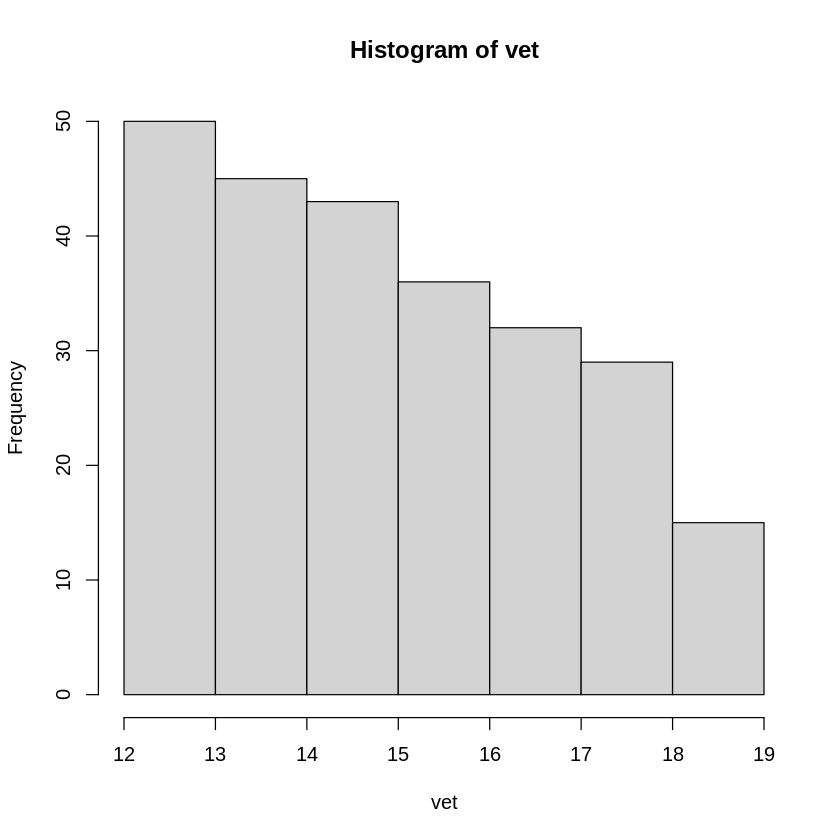

In [ ]:
vet <- amostra_ordenada[amostra]

hist(vet)

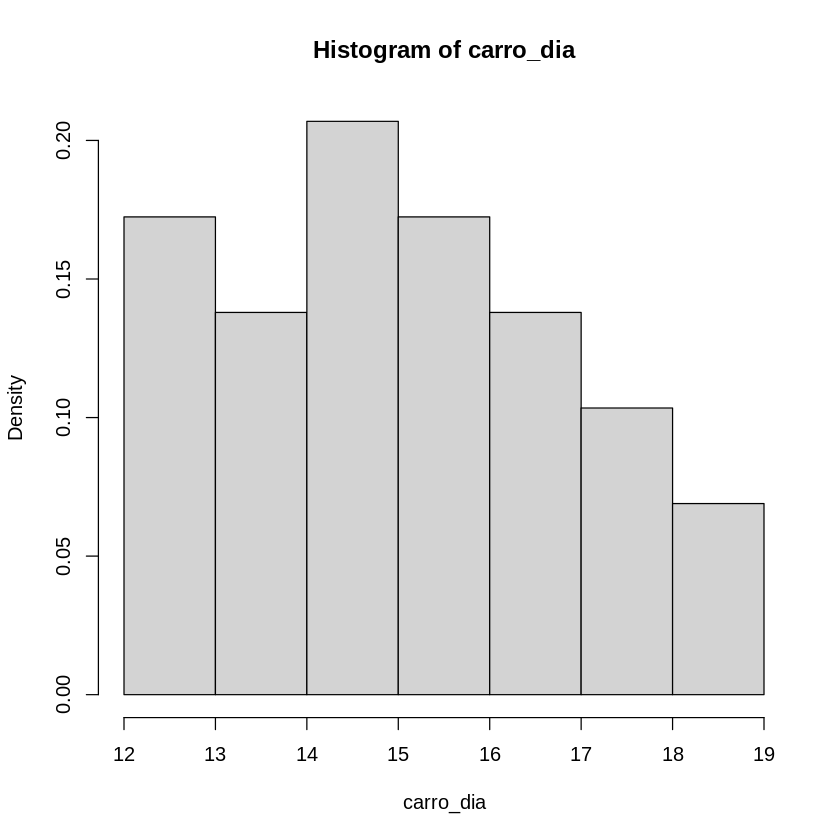

In [ ]:
hist(carro_dia, probability = TRUE)

##  Simulação Monte Carlo

In [ ]:
install.packages('triangle')
library(triangle)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
set.seed(1)
n_simulacao <- 3000

#### Matriz

In [ ]:
n_sim <- 3000
n_carros <- 20

sample_ativos <- sample(carro_dia, n_sim, replace = TRUE)

matriz_ativos <- matrix(0, nrow = n_sim, ncol = n_carros)

for(i in 1:n_sim){
  k <- sample_ativos[i]  # quantos carros ativos naquele dia

  ativos_indices <- sample(1:n_carros, k, replace = FALSE)
  matriz_ativos[i, ativos_indices] <- 1
}

matriz_consumo <- matrix(
  sample(litro_carro, n_sim * n_carros, replace = TRUE),
  nrow = n_sim,
  ncol = n_carros
)

matriz_consumo <- matriz_consumo * matriz_ativos
matriz_preco <- matrix(
  rtriangle(n_simulacao, 6.10, 7),
  nrow=n_sim,
  ncol=n_carros
)

matriz_consumo <- matriz_consumo * matriz_ativos
gasto <- rowSums(matriz_consumo * matriz_preco)

In [ ]:
summary(gasto)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3861    5083    5618    5651    6193    7702 

#### Resultados

In [ ]:
resumo_gasto <- c(
    #media = mean(gasto), # valor esperado do gasto diario
    desvio_padrao = sd(gasto), # variacao em torno da media
    mediana = median(gasto), # valor central da distribuicao
    minimo = min(gasto), # menor gasto simulado
    maximo = max(gasto), # maior gasto simulado
    p05 = as.numeric(quantile(gasto, 0.05)), # limite inferior da faixa usual
    p25 = as.numeric(quantile(gasto, 0.25)), # primeiro quartil
    p75 = as.numeric(quantile(gasto, 0.75)), # terceiro quartil
    p90 = as.numeric(quantile(gasto, 0.90)), # limite superior da faixa usual
    p95 = as.numeric(quantile(gasto, 0.95)), # limite superior da faixa usual
    cv = sd(gasto) / mean(gasto) # dispersao relativa da simulacao
)

In [ ]:
resumo_gasto_friendly <- data.frame(
    medida = names(resumo_gasto),
    valor = round(as.numeric(resumo_gasto), 2),
    row.names = NULL
)

print(resumo_gasto_friendly)

          medida   valor
1  desvio_padrao  735.45
2        mediana 5618.30
3         minimo 3860.93
4         maximo 7701.96
5            p05 4513.19
6            p25 5083.10
7            p75 6193.18
8            p90 6643.98
9            p95 6875.52
10            cv    0.13


### Gráficos

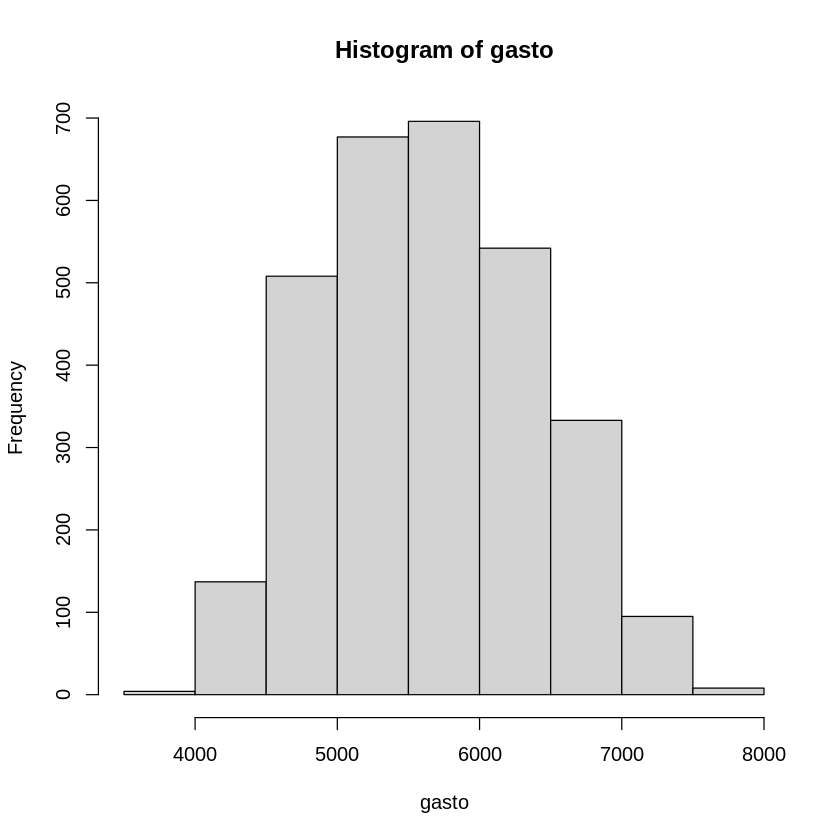

In [ ]:
hist(gasto)

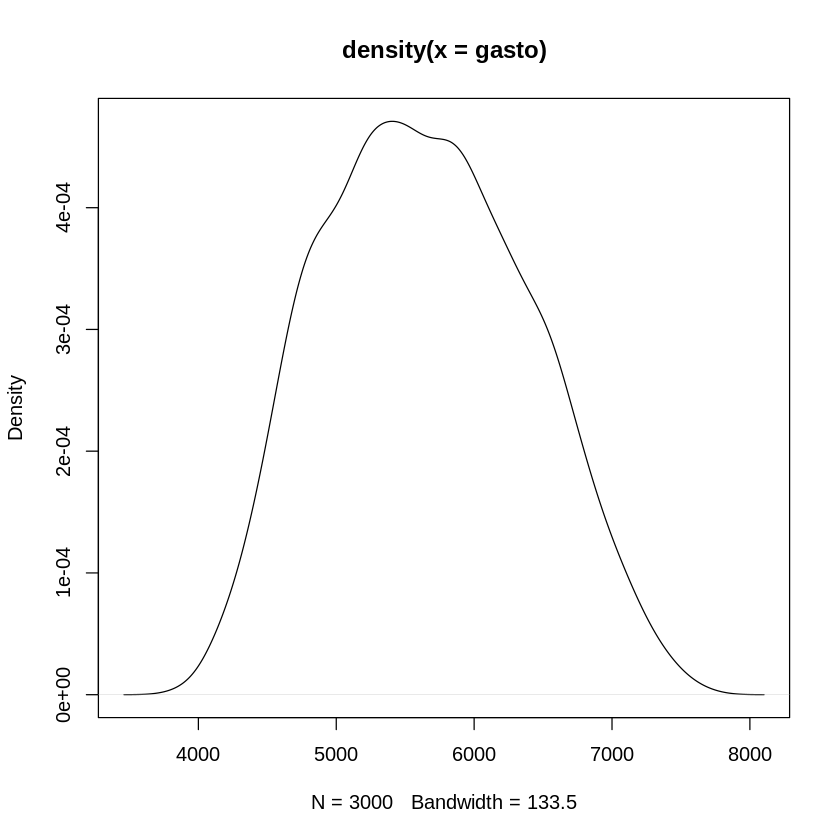

In [ ]:
plot(density(gasto))

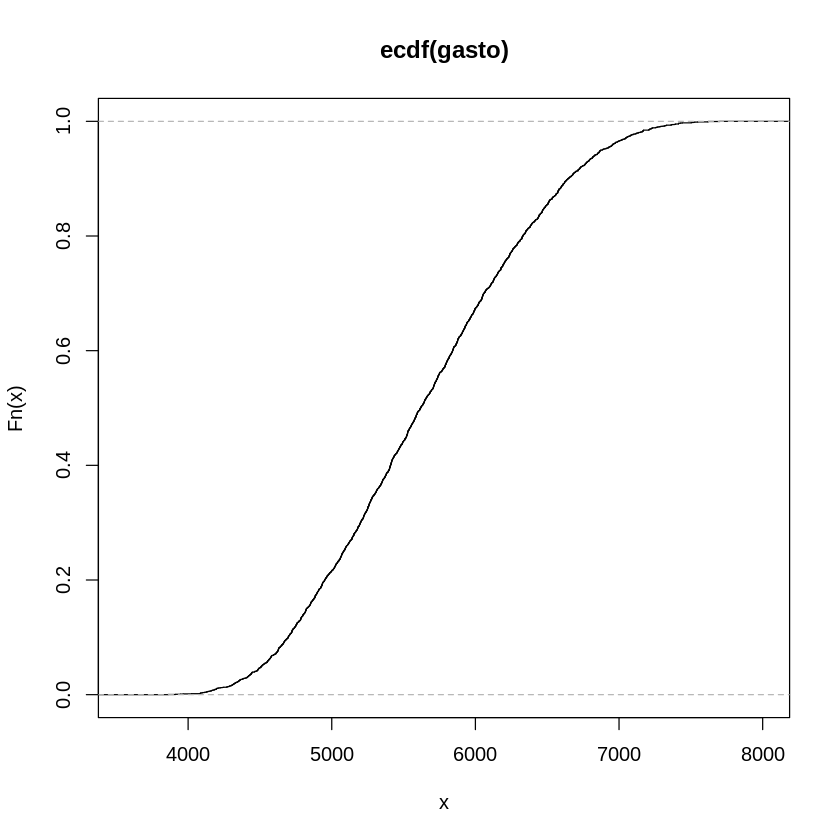

In [ ]:
plot(ecdf(gasto))

- sortear o número de carros no dia
- sortear um número de litros a ser consumido
- sortear o valor da gasolina

In [ ]:
# Estatísticas principais
custo_base <- quantile(gasto, 0.50)
custo_p90  <- quantile(gasto, 0.90)

# Contingência
contingencia <- custo_p90 - custo_base
percentual_contingencia <- (contingencia / custo_base) * 100

# Exibir resultados
cat(sprintf("P50 (mediana):      R$ %.2f\n", custo_base))
cat(sprintf("P90 (cenário risco): R$ %.2f\n", custo_p90))
cat(sprintf("Contingência:       R$ %.2f\n", contingencia))
cat(sprintf("Contingência %%:     %.2f%%\n", percentual_contingencia))

P50 (mediana):      R$ 5618.30
P90 (cenário risco): R$ 6643.98
Contingência:       R$ 1025.68
Contingência %:     18.26%


# item 2


In [ ]:
set.seed(1)
n_simulacao <- 3000

# Parâmetros para a distribuição triangular (número de executivos)
exec_min <- 16
exec_moda <- 18
exec_max <- 22

# Gastos por pessoa no último almoço
gasto_por_pessoa <- c(347, 410, 349, 454, 370, 465, 445, 383, 358, 418, 377, 407, 467, 441, 428, 354, 384, 400, 378, 367, 421, 392, 337, 387, 452, 411, 339, 380, 371, 464, 369, 484, 458, 471, 362)

# Número de almoços nos últimos 10 anos
almocos_ultimos10 <- c(38, 45, 42, 37, 38, 31, 42, 37, 42, 40)

##  Simulação Monte Carlo

In [ ]:
sample_presenca <- sample(round(rtriangle(n_simulacao, a = exec_min, b = exec_max, c = exec_moda)), n_sim, replace = TRUE)

matriz_presenca <- matrix(0, nrow = n_sim, ncol = exec_max)

for(i in 1:n_sim){
  k <- sample_presenca[i]  # quantos executivos estavam presentes naquele dia

  ativos_indices <- sample(1:exec_max, k, replace = FALSE)
  matriz_presenca[i, ativos_indices] <- 1
}


matriz_valor_por_pessoa <- matrix(
  sample(gasto_por_pessoa, n_simulacao, replace = TRUE),
  nrow = n_sim,
  ncol = exec_max
)

matriz_almocos_por_ano <- matrix(
  sample(almocos_ultimos10, n_simulacao, replace = TRUE),
  nrow = n_sim,
  ncol = 1
)

custo_por_pessoa <- matriz_valor_por_pessoa * matriz_presenca
custo_anual <- matriz_almocos_por_ano * rowSums(custo_por_pessoa)

In [ ]:
# Resumo estatístico do custo anual
resumo_custo <- c(
    media = mean(custo_anual), # valor esperado do custo anual
    desvio_padrao = sd(custo_anual), # variação absoluta
    mediana = median(custo_anual), # valor central
    minimo = min(custo_anual),
    maximo = max(custo_anual),
    p05 = as.numeric(quantile(custo_anual, 0.05)),
    p25 = as.numeric(quantile(custo_anual, 0.25)),
    p75 = as.numeric(quantile(custo_anual, 0.75)),
    p80 = as.numeric(quantile(custo_anual, 0.80)),
    p90 = as.numeric(quantile(custo_anual, 0.90)),
    p95 = as.numeric(quantile(custo_anual, 0.95)),
    cv = sd(custo_anual) / mean(custo_anual)
)

resumo_custo_friendly <- data.frame(
    medida = names(resumo_custo),
    valor = round(as.numeric(resumo_custo), 2),
    row.names = NULL
)

cat('\n--- Item 2: Resumo do custo anual (simulação) ---\n')
print(resumo_custo_friendly)


--- Item 2: Resumo do custo anual (simulação) ---
          medida     valor
1          media 293803.19
2  desvio_padrao  47179.92
3        mediana 291060.00
4         minimo 168144.00
5         maximo 457380.00
6            p05 218263.00
7            p25 260195.50
8            p75 324945.00
9            p80 334800.00
10           p90 355110.00
11           p95 372666.00
12            cv      0.16


In [ ]:
summary(custo_anual)

       V1        
 Min.   :168144  
 1st Qu.:260196  
 Median :291060  
 Mean   :293803  
 3rd Qu.:324945  
 Max.   :457380  

In [ ]:
# Estatísticas principais
custo_base <- quantile(custo_anual, 0.50)
custo_p90  <- quantile(custo_anual, 0.90)

# Contingência
contingencia <- custo_p90 - custo_base
percentual_contingencia <- (contingencia / custo_base) * 100

# Exibir resultados
cat(sprintf("P50 (mediana):      R$ %.2f\n", custo_base))
cat(sprintf("P90 (cenário risco): R$ %.2f\n", custo_p90))
cat(sprintf("Contingência:       R$ %.2f\n", contingencia))
cat(sprintf("Contingência %%:     %.2f%%\n", percentual_contingencia))

P50 (mediana):      R$ 291060.00
P90 (cenário risco): R$ 355110.00
Contingência:       R$ 64050.00
Contingência %:     22.01%


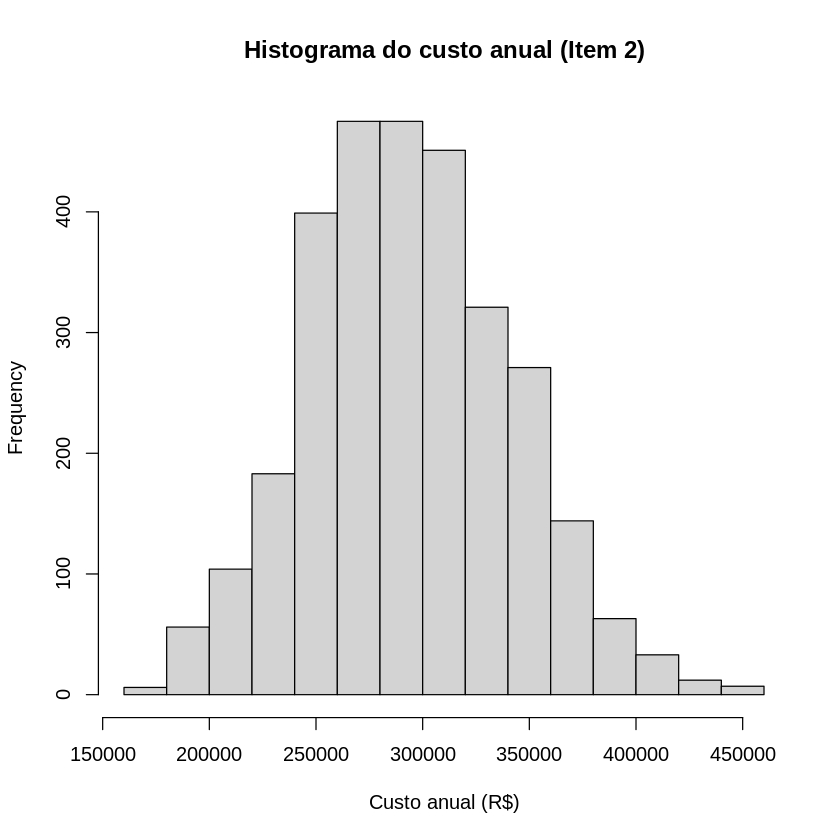

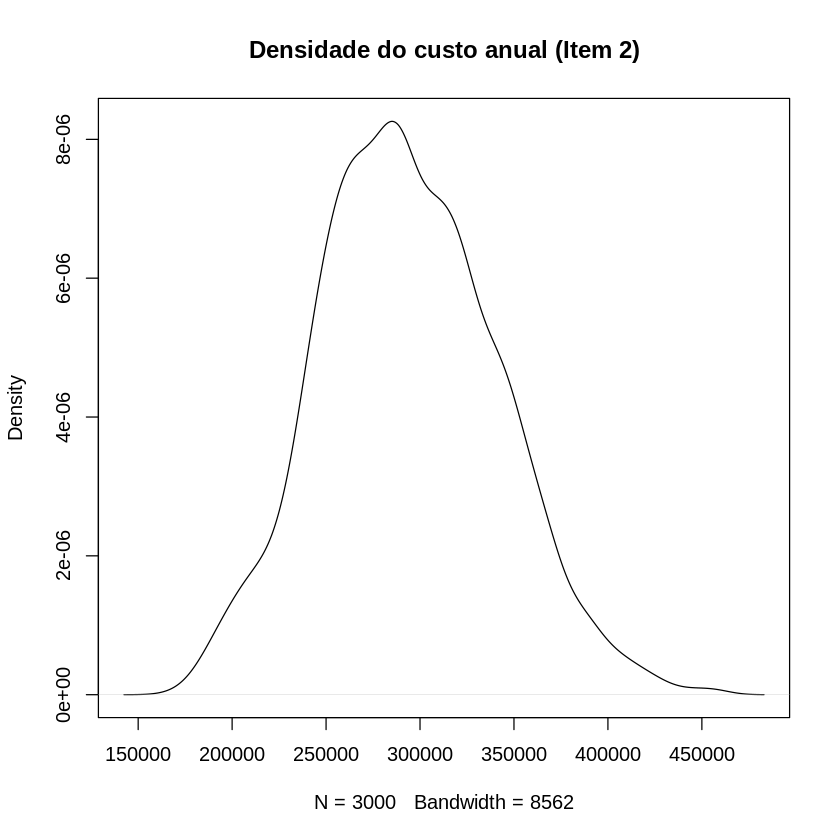

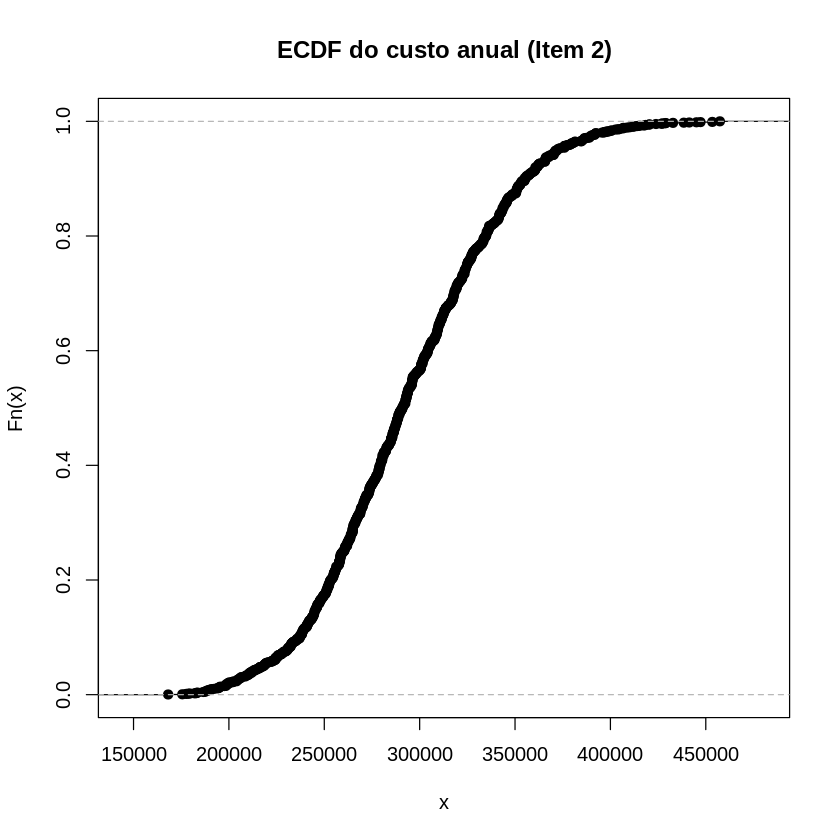

In [ ]:
# Visualizações rápidas
hist(custo_anual, main = 'Histograma do custo anual (Item 2)', xlab = 'Custo anual (R$)')
plot(density(custo_anual), main = 'Densidade do custo anual (Item 2)')
plot(ecdf(custo_anual), main = 'ECDF do custo anual (Item 2)')